## Import

In [1]:
import pandas as pd

# Load Scope 3 files
trading_df = pd.read_excel("raw_data/trading_and_imports.xlsx")
transport_df = pd.read_excel("raw_data/upstream_transportation.xlsx")
waste_df = pd.read_excel("raw_data/waste_disposal.xlsx")
travel_df = pd.read_excel("raw_data/business_travel.xlsx", skiprows=9)
warehouse_df = pd.read_excel("raw_data/warehousing_spend.xlsx")

# Preview top 5 rows for each
# print("\n📄 trading_and_imports.xlsx")
# display(trading_df.head())

# print("\n📄 upstream_transportation.xlsx")
# display(transport_df.head())

# print("\n📄 waste_disposal.xlsx")
# display(waste_df.head())

# print("\n📄 business_travel.xlsx")
# display(travel_df.head())

# print("\n📄 warehousing_spend.xlsx")
# display(warehouse_df.head())

## Trading and Import

In [2]:
 # Standardize "Nuts" to "Nut" in Material column
trading_df["Material"] = trading_df["Material"].replace("Nuts", "Nut")


# Use flexible keyword matching (e.g., "nut" matches "Nuts", "Cashew Nuts")
keywords = ["cocoa", "coffee", "sesame", "nut", "spice"]

for keyword in keywords:
    df = trading_df[trading_df["Material"].str.lower().str.contains(keyword)]
    globals()[f"trading_{keyword}_df"] = df
    print(f"{keyword}: {len(df)} rows")  # Optional: debug check
    
    
    
cocoa_emission_factors = {
    "Cocoa Beans": 26.447131,      # Closest match → cocoa powder
    "Cocoa Butter": 26.580789,     # Exact match
    "Cocoa Powder": 26.447131      # Exact match
}


coffee_emission_factors = {
    "Coffee Bean": 9.399578,        # Closest match → 'Coffee, ground'
    "Instant Coffee": 24.462185,    # Exact match → 'Coffee, powder, instant'
    "Liquid Coffee": 1.435118       # Closest match → 'Instant coffee, ready-to-drink'
}

sesame_emission_factors = {
    "Sesame": 6.063912  # Exact match → 'Sesame seed'
}

nut_emission_factors = {
    "Almond Whole": 5.050651,       # Proxy → cereal bar with almonds
    "Cashew Nuts Whole": 5.050651   # Same proxy — lacking specific cashew value
}

spice_emission_factors = {
    "Dehydrated Onion": 0.882389,   # Closest proxy - mix of 4 spices
    "Pepper": 0.882389              # Closest proxy - mix of 4 spices
}


# Combine all trading DFs and emission factor dictionaries
trading_dfs = {
    "cocoa": (trading_cocoa_df, cocoa_emission_factors),
    "coffee": (trading_coffee_df, coffee_emission_factors),
    "sesame": (trading_sesame_df, sesame_emission_factors),
    "nut": (trading_nut_df, nut_emission_factors),
    "spice": (trading_spice_df, spice_emission_factors)
}

# Store total emissions
summary_scope3_1 = {}


for key, (df, ef_dict) in trading_dfs.items():
    emission_col = f"Emissions: {key.title()} (tCO2e)"
    for product, ef in ef_dict.items():
        mask = df["Product Name"].str.lower().str.contains(product.lower(), na=False)
        df.loc[mask, emission_col] = df.loc[mask, "Volume(mt)"] * ef

# Rebuild summary
summary_scope3_1 = {}
for key, (df, _) in trading_dfs.items():
    col = f"Emissions: {key.title()} (tCO2e)"
    if col in df.columns:
        summary_scope3_1[key] = df[col].sum()

scope3_1_summary_df = pd.DataFrame.from_dict(summary_scope3_1, orient="index", columns=["Total Emissions (tCO2e)"])
scope3_1_summary_df.index.name = "Category"
scope3_1_summary_df


# Start with an empty list
normalized_rows = []

# Loop over each trading dataset and emission column
for category, (df, ef_dict) in trading_dfs.items():
    emission_col = f"Emissions: {category.title()} (tCO2e)"
    
    if emission_col in df.columns:
        # Group by Product Name and sum emissions
        grouped = df.groupby("Product Name")[emission_col].sum().reset_index()
        grouped.columns = ["Subcategory", "Emissions (tCO2e)"]
        grouped["Category"] = category.title()
        
        # Reorder
        grouped = grouped[["Subcategory", "Category", "Emissions (tCO2e)"]]
        
        # Append
        normalized_rows.append(grouped)

# Combine all results
clean_scope3_1_trading_GBcategory = pd.concat(normalized_rows, ignore_index=True)

# Sort for presentation
clean_scope3_1_trading_GBcategory = clean_scope3_1_trading_GBcategory.sort_values(["Category", "Emissions (tCO2e)"], ascending=[True, False])

# Display
clean_scope3_1_trading_GBcategory

# Start with two lists
category_rows = []
category_bu_rows = []

# Loop over each trading dataset and emission column
for category, (df, ef_dict) in trading_dfs.items():
    emission_col = f"Emissions: {category.title()} (tCO2e)"
    
    if emission_col in df.columns:
        # ----- Group by Category + Subcategory -----
        grouped_cat = df.groupby("Product Name")[emission_col].sum().reset_index()
        grouped_cat.columns = ["Subcategory", "Emissions (tCO2e)"]
        grouped_cat["Category"] = category.title()
        grouped_cat = grouped_cat[["Subcategory", "Category", "Emissions (tCO2e)"]]
        category_rows.append(grouped_cat)
        
        # ----- Group by Category + Subcategory + BU -----
        if "BU" in df.columns:
            grouped_bu = df.groupby(["BU", "Product Name"])[emission_col].sum().reset_index()
            grouped_bu.columns = ["BU", "Subcategory", "Emissions (tCO2e)"]
            grouped_bu["Category"] = category.title()
            grouped_bu = grouped_bu[["BU", "Subcategory", "Category", "Emissions (tCO2e)"]]
            category_bu_rows.append(grouped_bu)

# Combine
clean_scope3_1_trading_GBcategory = pd.concat(category_rows, ignore_index=True).sort_values(
    ["Category", "Emissions (tCO2e)"], ascending=[True, False]
)

clean_scope3_1_trading_GBcategory_BU = pd.concat(category_bu_rows, ignore_index=True).sort_values(
    ["Category", "BU", "Emissions (tCO2e)"], ascending=[True, True, False]
)

# Display
display(clean_scope3_1_trading_GBcategory)
display(clean_scope3_1_trading_GBcategory_BU)

cocoa: 29 rows
coffee: 29 rows
sesame: 6 rows
nut: 4 rows
spice: 6 rows


/var/folders/bf/t7zr8nds6f727x199sygjpbh0000gn/T/ipykernel_9073/3061413956.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[mask, emission_col] = df.loc[mask, "Volume(mt)"] * ef
/var/folders/bf/t7zr8nds6f727x199sygjpbh0000gn/T/ipykernel_9073/3061413956.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[mask, emission_col] = df.loc[mask, "Volume(mt)"] * ef
/var/folders/bf/t7zr8nds6f727x199sygjpbh0000gn/T/ipykernel_9073/3061413956.py:60: SettingWithCopyWarning: 
A value is trying to be set

,Subcategory,Category,Emissions (tCO2e)
2,Cocoa Powder,Cocoa,239822.583908
0,Cocoa Beans,Cocoa,80743.090943
1,Cocoa Butter,Cocoa,66664.618812
3,Coffee Bean,Coffee,485958.182600
4,Instant Coffee,Coffee,95402.521500
5,Liquid Coffee,Coffee,16647.368800
7,Almond Whole,Nut,7363.849158
8,Cashew Nuts Whole,Nut,4131.432518
6,Sesame,Sesame,312897.859200
9,Dehydrated Onion,Spice,2366.567298


,BU,Subcategory,Category,Emissions (tCO2e)
2,BU10,Cocoa Powder,Cocoa,239822.583908
0,BU10,Cocoa Beans,Cocoa,80743.090943
1,BU10,Cocoa Butter,Cocoa,66664.618812
3,BU11,Coffee Bean,Coffee,485958.182600
4,BU11,Instant Coffee,Coffee,95402.521500
5,BU11,Liquid Coffee,Coffee,16647.368800
7,BU10,Almond Whole,Nut,7363.849158
8,BU10,Cashew Nuts Whole,Nut,4131.432518
6,BU4,Sesame,Sesame,312897.859200
9,BU4,Dehydrated Onion,Spice,2366.567298


## Transport

In [3]:
# # Display results
# display(transport_summary_by_category.sort_values("Emissions (kgCO2e)", ascending=False))
# display(transport_summary_by_bu.sort_values(["Category", "BU", "Emissions (kgCO2e)"], ascending=[True, True, False]))

In [4]:
# --- Clean Columns ---
transport_df.columns = transport_df.columns.str.strip().str.lower().str.replace(' ', '_')

# --- Keep Relevant Columns & Rename ---
transport_df = transport_df[[
    'bu', 'product_name', 'volume(mt)', 'distance(km)'
]].rename(columns={
    'volume(mt)': 'volume_mt',
    'distance(km)': 'distance_km'
}).dropna(subset=['bu', 'product_name', 'volume_mt', 'distance_km']).reset_index(drop=True)

# --- Emission Factors (kg CO2e / tonne·km) ---
emission_factors = {
    "Sesame": 6.063912,
    "Cocoa Beans": 26.447131,
    "Cocoa Mass": 26.447131,
    "Cocoa Preparation": 26.447131,
    "Coffee Bean": 9.399578,
    "Cocoa Butter": 26.525000,
    "Cocoa Powder": 26.447131,
    "Instant Coffee": 24.462185,
    "Liquid Coffee": 1.435118,
    "Almond Whole": 5.050651,
    "Almond Ingredient": 5.050651,
    "Dehydrated Onion": 0.882389,
    "Cashew Nuts Whole": 5.050651,
    "Pepper": 0.882389
}

# --- Calculate Emissions in tCO2e ---
transport_df["emission_factor"] = transport_df["product_name"].map(emission_factors)
transport_df["emissions_tco2e"] = (
    transport_df["volume_mt"] * transport_df["distance_km"] * transport_df["emission_factor"] / 1000
)

# --- Label Category ---
transport_df["category"] = "Transport"

# --- Group by Product (Subcategory) ---
transport_summary_by_category = (
    transport_df.groupby("product_name")["emissions_tco2e"]
    .sum().reset_index()
    .rename(columns={"product_name": "Subcategory", "emissions_tco2e": "Emissions (tCO2e)"})
)
transport_summary_by_category["Category"] = "Transport"
transport_summary_by_category = transport_summary_by_category[["Subcategory", "Category", "Emissions (tCO2e)"]]

# --- Group by BU + Product ---
transport_summary_by_bu = (
    transport_df.groupby(["bu", "product_name"])["emissions_tco2e"]
    .sum().reset_index()
    .rename(columns={"bu": "BU", "product_name": "Subcategory", "emissions_tco2e": "Emissions (tCO2e)"})
)
transport_summary_by_bu["Category"] = "Transport"
transport_summary_by_bu = transport_summary_by_bu[["BU", "Subcategory", "Category", "Emissions (tCO2e)"]]

# --- Display results ---
display(transport_summary_by_category.sort_values("Emissions (tCO2e)", ascending=False))
display(transport_summary_by_bu.sort_values(["Category", "BU", "Emissions (tCO2e)"], ascending=[True, True, False]))

,Subcategory,Category,Emissions (tCO2e)
8,Coffee Bean,Transport,7.096017e+06
13,Sesame,Transport,5.592673e+06
6,Cocoa Powder,Transport,3.282987e+06
5,Cocoa Mass,Transport,1.772166e+06
3,Cocoa Beans,Transport,1.609851e+06
4,Cocoa Butter,Transport,5.831779e+05
7,Cocoa Preparation,Transport,5.713299e+05
10,Instant Coffee,Transport,4.283988e+05
11,Liquid Coffee,Transport,1.431315e+05
9,Dehydrated Onion,Transport,2.403717e+04


,BU,Subcategory,Category,Emissions (tCO2e)
2,BU5,Sesame,Transport,5.592673e+06
0,BU5,Dehydrated Onion,Transport,2.403717e+04
1,BU5,Pepper,Transport,8.402453e+02
9,BU6,Cocoa Powder,Transport,3.282987e+06
8,BU6,Cocoa Mass,Transport,1.772166e+06
6,BU6,Cocoa Beans,Transport,1.609851e+06
7,BU6,Cocoa Butter,Transport,5.831779e+05
10,BU6,Cocoa Preparation,Transport,5.713299e+05
4,BU6,Almond Whole,Transport,1.869337e+04
3,BU6,Almond Ingredient,Transport,1.585739e+04


## Waste

In [5]:
print("\n📄 waste_disposal.xlsx")
display(waste_df.head())


📄 waste_disposal.xlsx


,Timeperiod,BU,Material,Material Type,Product Name,Warehouse Site Location,Disposal method,annual Quantity(MT)
0,2021,BU1,Sesame,Raw Material,Sesame,Kobe,incineration,70
1,2021,BU1,Sesame,Raw Material,Sesame,Yokohama,incineration,30
2,2021,BU1,Sesame,Raw Material,Sesame,Nagoya,incineration,220
3,2021,BU1,Sesame,Raw Material,Sesame,Yokohama,incineration,30
4,2021,BU2,Cocoa,Processed goods,Cocoa powder,Kobe,composting,200


In [6]:
# waste_df["Disposal method"].unique()

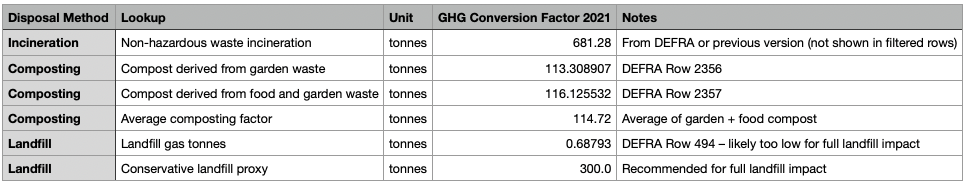

In [7]:
# --- Standardize Column Names ---
waste_df.columns = waste_df.columns.str.strip().str.lower().str.replace(' ', '_')

# --- Keep Relevant Fields ---
waste_df = waste_df[[
    'bu', 'product_name', 'disposal_method', 'annual_quantity(mt)'
]].rename(columns={
    'annual_quantity(mt)': 'quantity_mt'
}).dropna(subset=['bu', 'product_name', 'disposal_method', 'quantity_mt']).reset_index(drop=True)

# --- Updated Emission Factors (kg CO2e per tonne) from DEFRA ---
disposal_ef = {
    "incineration": 681.277905,   # From DEFRA - internet look up
    "composting": 114.72,      # From DEFRA - taking an average of 2 composting related rows - 2356, 2357
    "landfill": 300.0             # Cited from Scope 3 plastic examples
}

# --- Apply Emission Factor & Convert to tCO2e ---
waste_df["disposal_method"] = waste_df["disposal_method"].str.strip().str.lower()
waste_df["emission_factor"] = waste_df["disposal_method"].map(disposal_ef)
waste_df["emissions_tco2e"] = waste_df["quantity_mt"] * waste_df["emission_factor"] / 1000

# --- Label Category ---
waste_df["category"] = "Waste"

# --- Group by Product (Subcategory) ---
waste_summary_by_category = (
    waste_df.groupby("product_name")["emissions_tco2e"]
    .sum().reset_index()
    .rename(columns={"product_name": "Subcategory", "emissions_tco2e": "Emissions (tCO2e)"})
)
waste_summary_by_category["Category"] = "Waste"
waste_summary_by_category = waste_summary_by_category[["Subcategory", "Category", "Emissions (tCO2e)"]]

# --- Group by BU + Product ---
waste_summary_by_bu = (
    waste_df.groupby(["bu", "product_name"])["emissions_tco2e"]
    .sum().reset_index()
    .rename(columns={"bu": "BU", "product_name": "Subcategory", "emissions_tco2e": "Emissions (tCO2e)"})
)
waste_summary_by_bu["Category"] = "Waste"
waste_summary_by_bu = waste_summary_by_bu[["BU", "Subcategory", "Category", "Emissions (tCO2e)"]]

# --- Display Results ---
display(waste_summary_by_category.sort_values("Emissions (tCO2e)", ascending=False))
display(waste_summary_by_bu.sort_values(["Category", "BU", "Emissions (tCO2e)"], ascending=[True, True, False]))

,Subcategory,Category,Emissions (tCO2e)
2,Sesame,Waste,238.447267
1,Onion,Waste,100.500000
0,Cocoa powder,Waste,65.849280


,BU,Subcategory,Category,Emissions (tCO2e)
0,BU1,Sesame,Waste,238.447267
1,BU2,Cocoa powder,Waste,65.849280
2,BU3,Onion,Waste,100.500000


In [8]:
print("\n📄 business_travel.xlsx")
display(travel_df.head())


📄 business_travel.xlsx


,Unnamed: 0,No,BU,City Pairs,# of trips,Distance (km),Distance (miles),Emission Factor (kg/unit),Emission (kg/CO2e),Total (kg/CO2e),Total (ton/CO2e)
0,NaN,1,BU1,CGK - PKU,179,930,577.875030,0.129,74.545879,13343.712320,13.343712
1,NaN,2,BU2,DJB - PKU,1,337,209.402027,0.207,43.346220,43.346220,0.043346
2,NaN,3,BU3,PKU - BDJ,1,1543,958.775453,0.129,123.682033,123.682033,0.123682
3,NaN,4,BU1,PKU - CGK,130,930,577.875030,0.129,74.545879,9690.964253,9.690964
4,NaN,5,BU2,PKU - DJB,4,337,209.402027,0.207,43.346220,173.384878,0.173385


In [9]:
# --- Standardize columns ---
travel_df.columns = travel_df.columns.str.strip().str.lower().str.replace(' ', '_')

# --- Rename and filter relevant columns ---
travel_df = travel_df.rename(columns={'total_(ton/co2e)': 'emissions_tco2e'})

# --- Add Category label ---
travel_df["category"] = "Business Travel"

# --- Group by Subcategory (City Pairs) ---
travel_summary_by_category = (
    travel_df.groupby("city_pairs")["emissions_tco2e"]
    .sum().reset_index()
    .rename(columns={"city_pairs": "Subcategory", "emissions_tco2e": "Emissions (tCO2e)"})
)
travel_summary_by_category["Category"] = "Business Travel"
travel_summary_by_category = travel_summary_by_category[["Subcategory", "Category", "Emissions (tCO2e)"]]

# --- Group by BU + City Pairs ---
travel_summary_by_bu = (
    travel_df.groupby(["bu", "city_pairs"])["emissions_tco2e"]
    .sum().reset_index()
    .rename(columns={"bu": "BU", "city_pairs": "Subcategory", "emissions_tco2e": "Emissions (tCO2e)"})
)
travel_summary_by_bu["Category"] = "Business Travel"
travel_summary_by_bu = travel_summary_by_bu[["BU", "Subcategory", "Category", "Emissions (tCO2e)"]]

# --- Display both summaries ---
display(travel_summary_by_category.sort_values("Emissions (tCO2e)", ascending=False))
display(travel_summary_by_bu.sort_values(["Category", "BU", "Emissions (tCO2e)"], ascending=[True, True, False]))


,Subcategory,Category,Emissions (tCO2e)
0,CGK - PKU,Business Travel,13.343712
3,PKU - CGK,Business Travel,9.690964
10,PKU - PKN,Business Travel,1.050135
16,PKY - PKU,Business Travel,1.025847
15,PKU - YIA,Business Travel,0.852869
11,PKU - PKY,Business Travel,0.683898
8,PKU - KTG,Business Travel,0.471803
5,PKU - DJJ,Business Travel,0.441697
19,SRG - PKU,Business Travel,0.412968
6,PKU - HLP,Business Travel,0.384352


,BU,Subcategory,Category,Emissions (tCO2e)
0,BU1,CGK - PKU,Business Travel,13.343712
1,BU1,PKU - CGK,Business Travel,9.690964
5,BU1,PKU - YIA,Business Travel,0.852869
2,BU1,PKU - HLP,Business Travel,0.384352
6,BU1,SMQ - PKU,Business Travel,0.318383
3,BU1,PKU - PGK,Business Travel,0.143801
7,BU1,TJQ - PKU,Business Travel,0.063083
4,BU1,PKU - PLM,Business Travel,0.041601
11,BU2,PKU - PKN,Business Travel,1.050135
13,BU2,PKY - PKU,Business Travel,1.025847


## Warehouse
- Estimate Based on Spend
- emission_factor_warehouse = 0.15
- CEDA - 0.12–0.20 kg CO₂e per $ spent

In [10]:
print("\n📄 warehousing_spend.xlsx")
display(warehouse_df.head())


📄 warehousing_spend.xlsx


,Fiscal Year,BU,Material,Mateial Type,Product Name,Warehouse Site Location,annual Quantity (mt),warehouse Spend $/mt,warehouse Spend (KXM)
0,2021,BU1,Coffee,Raw Material,Coffee Bean,Yokohama,14300,86.5,1236950.0
1,2021,BU1,Coffee,Raw Material,Coffee Bean,Nagoya,400,86.5,34600.0
2,2021,BU1,Coffee,Raw Material,Coffee Bean,Kobe,4500,86.5,389250.0
3,2021,BU1,Coffee,Raw Material,Coffee Bean,Fukuoka,1100,86.5,95150.0
4,2021,BU1,Coffee,Raw Material,Coffee Bean,Fukuoka,1500,86.5,129750.0


In [11]:
# --- Standardize Column Names ---
warehouse_df.columns = warehouse_df.columns.str.strip().str.lower().str.replace(' ', '_')

# --- Keep Relevant Fields ---
warehouse_df = warehouse_df[[
    'bu', 'product_name', 'warehouse_spend_$/mt', 'warehouse_spend_(kxm)'
]].rename(columns={
    'warehouse_spend_$/mt': 'spend_per_mt',
    'warehouse_spend_(kxm)': 'total_spend_usd'
}).dropna(subset=['bu', 'product_name', 'total_spend_usd']).reset_index(drop=True)

# --- Assumed Emission Factor (kg CO2e per USD spent) ---
WAREHOUSE_EF_PER_DOLLAR = 0.15

# --- Apply Emission Factor & Convert to tCO2e ---
warehouse_df["emissions_tco2e"] = warehouse_df["total_spend_usd"] * WAREHOUSE_EF_PER_DOLLAR / 1000
warehouse_df["category"] = "Warehousing"

# --- Group by Product Name (Subcategory) ---
warehouse_summary_by_category = (
    warehouse_df.groupby("product_name")["emissions_tco2e"]
    .sum().reset_index()
    .rename(columns={"product_name": "Subcategory", "emissions_tco2e": "Emissions (tCO2e)"})
)
warehouse_summary_by_category["Category"] = "Warehousing"
warehouse_summary_by_category = warehouse_summary_by_category[["Subcategory", "Category", "Emissions (tCO2e)"]]

# --- Group by BU + Product ---
warehouse_summary_by_bu = (
    warehouse_df.groupby(["bu", "product_name"])["emissions_tco2e"]
    .sum().reset_index()
    .rename(columns={"bu": "BU", "product_name": "Subcategory", "emissions_tco2e": "Emissions (tCO2e)"})
)
warehouse_summary_by_bu["Category"] = "Warehousing"
warehouse_summary_by_bu = warehouse_summary_by_bu[["BU", "Subcategory", "Category", "Emissions (tCO2e)"]]

# --- Display Results ---
display(warehouse_summary_by_category.sort_values("Emissions (tCO2e)", ascending=False))
display(warehouse_summary_by_bu.sort_values(["Category", "BU", "Emissions (tCO2e)"], ascending=[True, True, False]))

,Subcategory,Category,Emissions (tCO2e)
7,Coffee Bean,Warehousing,282.855000
9,Liquid Coffee,Warehousing,102.240000
10,Sesame,Warehousing,30.858300
8,Instant Coffee,Warehousing,22.057500
5,Cocoa Powder,Warehousing,7.145856
0,Almond Ingredient,Warehousing,3.993132
3,Cocoa Beans,Warehousing,3.919500
4,Cocoa Mass,Warehousing,2.695860
6,Cocoa Preparation,Warehousing,2.455200
2,Cashew Nuts Whole,Warehousing,2.017538


,BU,Subcategory,Category,Emissions (tCO2e)
0,BU1,Coffee Bean,Warehousing,282.855000
2,BU1,Liquid Coffee,Warehousing,102.240000
1,BU1,Instant Coffee,Warehousing,22.057500
8,BU2,Cocoa Powder,Warehousing,7.145856
3,BU2,Almond Ingredient,Warehousing,3.993132
6,BU2,Cocoa Beans,Warehousing,3.919500
7,BU2,Cocoa Mass,Warehousing,2.695860
9,BU2,Cocoa Preparation,Warehousing,2.455200
5,BU2,Cashew Nuts Whole,Warehousing,2.017538
4,BU2,Almond Whole,Warehousing,1.619352
